##Kaggle JSON upload

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "mohamedhelmykroush",\r\n  "key": "KGAT_3104e7540e55bb57e379316a525ea4f4"\r\n}\r\n'}

##Create Kaggle dir


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


##kaggle data install

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d saumyapatel/traffic-vehicles-object-detection

Dataset URL: https://www.kaggle.com/datasets/saumyapatel/traffic-vehicles-object-detection
License(s): unknown
 96% 585M/607M [00:06<00:00, 163MB/s]
100% 607M/607M [00:06<00:00, 94.1MB/s]


##Unzip Dataset

In [ ]:
!unzip traffic-vehicles-object-detection.zip

Archive:  traffic-vehicles-object-detection.zip
  inflating: Traffic Dataset/images/test/00 (1).png  
  inflating: Traffic Dataset/images/test/00 (10).png  
  inflating: Traffic Dataset/images/test/00 (100).png  
  inflating: Traffic Dataset/images/test/00 (11).png  
  inflating: Traffic Dataset/images/test/00 (12).png  
  inflating: Traffic Dataset/images/test/00 (13).png  
  inflating: Traffic Dataset/images/test/00 (14).png  
  inflating: Traffic Dataset/images/test/00 (15).png  
  inflating: Traffic Dataset/images/test/00 (16).png  
  inflating: Traffic Dataset/images/test/00 (17).png  
  inflating: Traffic Dataset/images/test/00 (174).jpg  
  inflating: Traffic Dataset/images/test/00 (175).jpg  
  inflating: Traffic Dataset/images/test/00 (176).jpg  
  inflating: Traffic Dataset/images/test/00 (177).jpg  
  inflating: Traffic Dataset/images/test/00 (178).jpg  
  inflating: Traffic Dataset/images/test/00 (179).jpg  
  inflating: Traffic Dataset/images/test/00 (18).png  
  inflating

##ultralytics install

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.8 MB/s eta 0:00:00


##YAML Style

In [ ]:
import yaml
import os

def create_data_yaml(dataset_path, output_yaml='data.yaml'):
    classes_txt_path = os.path.join(dataset_path, 'classes.txt')
    if not os.path.exists(classes_txt_path):
        print(f'classes.txt not found at {classes_txt_path}')
        return

    with open(classes_txt_path, 'r') as f:
        classes = [line.strip() for line in f.readlines() if line.strip()]

    data = {
        'path': dataset_path,
        'train': 'images/train',
        'val': 'images/val',
        'nc': len(classes),
        'names': classes
    }

    yaml_path = os.path.join(dataset_path, output_yaml)
    with open(yaml_path, 'w') as f:
        yaml.dump(data, f, sort_keys=False)

    print(f'Data YAML created at {yaml_path}')
    return yaml_path


In [ ]:
dataset_path = './Traffic Dataset'
yaml_path = create_data_yaml(dataset_path)


Data YAML created at ./Traffic Dataset/data.yaml


##YOLO Model

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8m.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


##Yolo Training

In [ ]:
model.train(
    data="./Traffic Dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2,

    fliplr=0.5,
    flipud=0.0,

    mosaic=1.0,
    mixup=0.2


)


Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./Traffic Dataset/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0

##YOLO Model befor and after training

In [ ]:
import matplotlib.pyplot as plt



image 1/1 /content/OIP.webp: 640x640 14 cars, 2 buss, 1 truck, 5.8ms
Speed: 2.2ms preprocess, 5.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


(np.float64(-0.5), np.float64(239.5), np.float64(240.5), np.float64(-0.5))

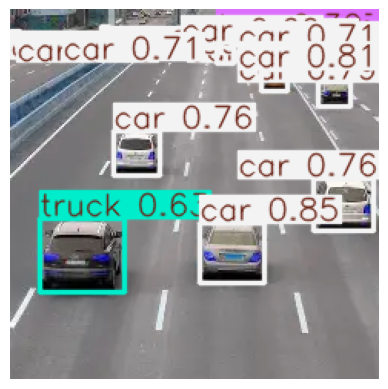

In [ ]:
base_model = YOLO("yolov8n.pt")
results = base_model("OIP.webp", conf=0.25)
plt.imshow(results[0].plot())
plt.axis("off")


image 1/1 /content/OIP.webp: 640x640 13 Cars, 4 Blur Number Plates, 9.7ms
Speed: 2.9ms preprocess, 9.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


(np.float64(-0.5), np.float64(239.5), np.float64(240.5), np.float64(-0.5))

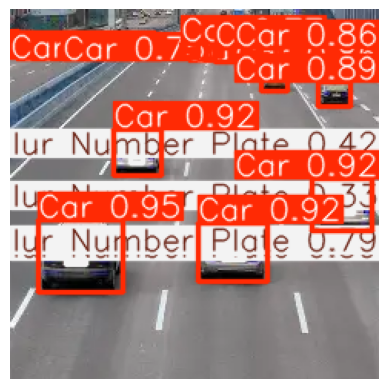

In [ ]:
results1 = model("OIP.webp", conf=0.25, classes = [0,3,4,5,6])
plt.imshow(results1[0].plot())
plt.axis("off")

##Video Demo

In [ ]:

model("Vehicle Dataset Sample 2(720P_HD).mp4", conf=0.25, save=True, classes = [0,3,4,5,6])


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/302) /content/Vehicle Dataset Sample 2(720P_HD).mp4: 384x640 2 Cars, 46.5ms
video 1/1 (frame 2/302) /content/Vehicle Dataset Sample 2(720P_HD).mp4: 384x640 2 Cars, 7.2ms
video 1/1 (frame 3/302) /content/Vehicle Dataset Sample 2(720P_HD).mp4: 384x640 2 Cars, 8.9ms
video 1/1 (frame 4/302) /content/Vehicle Dataset Sample 2(720P_HD).mp4: 384x640 2 Cars, 6.7ms
video 1/1 (frame 5/302) /content/Vehicle Dataset Sample 2(720P_HD).mp4: 384x640 2

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Car', 1: 'Number Plate', 2: 'Blur Number Plate', 3: 'Two Wheeler', 4: 'Auto', 5: 'Bus', 6: 'Truck'}
 obb: None
 orig_img: array([[[ 20,  35,  33],
         [ 19,  34,  32],
         [ 19,  34,  32],
         ...,
         [138, 128, 128],
         [137, 127, 127],
         [136, 126, 126]],
 
        [[ 20,  35,  33],
         [ 19,  34,  32],
         [ 18,  33,  31],
         ...,
         [140, 130, 130],
         [139, 129, 129],
         [139, 129, 129]],
 
        [[ 23,  40,  38],
         [ 19,  36,  34],
         [ 16,  33,  31],
         ...,
         [139, 129, 129],
         [140, 130, 130],
         [141, 131, 131]],
 
        ...,
 
        [[116, 118, 120],
         [106, 108, 110],
         [122, 124, 126],
         ...,
         [111, 108, 109],
         [111, 108, 109],
         [111, 108, 109]],
 
        [[134, 136,

##Model Evulation

In [ ]:
trained_metrics = model.val(data="./Traffic Dataset/data.yaml")
print(trained_metrics.box.map50)


Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2695.0±995.7 MB/s, size: 486.5 KB)
val: Scanning /content/Traffic Dataset/labels/val.cache... 185 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 185/185 344.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.7it/s 4.4s
                   all        185       1980      0.849      0.707      0.803      0.548
                   Car        159       1061      0.918      0.896      0.947      0.771
          Number Plate        104        174      0.858      0.762      0.824       0.51
     Blur Number Plate         80        161      0.905      0.472      0.679      0.344
           Two Wheeler         88        271      0.893      0.865      0.904       0.63
                  Auto         44         94       0.75      0.573      0.625      0.314
                   Bus         9

##Saving Model

In [ ]:
model.save("best.pt")

##GUI

In [ ]:
!pip install gradio


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import gradio as gr
import cv2
import tempfile
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("best.pt")

In [ ]:
def detect_image_or_video(file):
    ext = os.path.splitext(file.name)[1].lower()


    if ext in [".jpg", ".jpeg", ".png", ".webp"]:
        results = model(file.name, conf=0.25, classes = [0,3,4,5,6])
        annotated_img = results[0].plot()

        return annotated_img, None


    elif ext in [".mp4", ".avi", ".mov"]:
     results = model(
        file.name,
        conf=0.25,
        classes=[0, 3, 4, 5, 6],
        save=True
    )

     return None, results

In [ ]:
iface = gr.Interface(
    fn=detect_image_or_video,
    inputs=gr.File(label="Upload Image or Video"),
    outputs=[
        gr.Image(type="numpy", label="Detected Image"),
        gr.Video(label="Detected Video")
    ],
    title="YOLOv8 Image & Video Detection + Tracker",
    description="Supports images (.jpg, .png, .webp) and videos. Counts each object once for the whole video."
)

iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4601830c1ad5cddb17.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
